In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel
from numba import njit
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from sklearn.cluster import AgglomerativeClustering


In [2]:
df = pd.read_csv('../data/updated_data.csv')

In [3]:
y = df["fem_empl_rate"].to_numpy()
y = y / 100
y_star = np.log(y / (1 - y))

selected_covariates = ["coverage", "per_capita_user_contribution", "ageing_index", "ecec_participation", "per_capita_public_expenditure", "service_empl_rate", "ecec_diffusion", "n_members_family", "avg_children_per_woman", "fem_house_rate"]
X = df[selected_covariates].to_numpy()
X_scaler = StandardScaler()
X_star = X_scaler.fit_transform(X)

offset = df["wr_men"].to_numpy()
offset = offset / 100
offset_star = np.log(offset / (1 - offset))

N = 107 
P = len(selected_covariates) 
K = 3 

## Label Assignment

We might consider to add in the model the spatial effect

In [4]:
mix_model = """
data {
  int<lower=1> N;          
  int<lower=1> P;          
  int<lower=1> K;          
  vector[N] y_star;             
  matrix[N, P] X_star;          
  vector[N] offset_star;        
}

parameters {
  simplex[K] pi;           
  vector[K] alpha;         
  vector[P] beta; 
  vector<lower=1e-6>[K] sigma; 
}

model {
  // Priors
  pi ~ dirichlet(rep_vector(1.0, K)); 
  sigma ~ normal(0, 1);

  for (k in 1:K) {
    alpha[k] ~ normal(0, 1);
  }

  for (j in 1:P) {
    beta[j] ~ normal(0, 1);
  }

  // Likelihood
  for (i in 1:N) {
    vector[K] lps;
    for (k in 1:K) {
      real mu_ik;
      mu_ik = alpha[k] + dot_product(row(X_star, i), beta) + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }
    target += log_sum_exp(lps);
  }
}

generated quantities {
  array[N] int z;

  for (i in 1:N) {
    vector[K] lps;
    vector[K] r_i;

    for (k in 1:K) {
      real mu_ik = alpha[k] + X_star[i] * beta + offset_star[i];
      lps[k] = log(pi[k]) + normal_lpdf(y_star[i] | mu_ik, sigma);
    }

    r_i = softmax(lps);
    z[i] = categorical_rng(r_i);
  }
}

"""

In [5]:
with open("normal_mixture.stan", "w") as f:
    f.write(mix_model)

In [6]:
data = {
    "N": int(N),
    "P": int(P),
    "K": int(K),
    "y_star": y_star.astype(float),
    "X_star": X_star.astype(float),
    "offset_star": offset_star.astype(float),
}


In [7]:
mix_stan = CmdStanModel(stan_file="normal_mixture.stan")

16:02:59 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.exe
16:05:31 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\normal_mixture.exe


In [8]:
fit = mix_stan.sample(
    data=data,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

16:06:03 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

16:06:45 - cmdstanpy - INFO - CmdStan done processing.


In [9]:
fit.stan_variables().keys()

dict_keys(['pi', 'alpha', 'beta', 'sigma', 'z'])

In [10]:
z_draws = fit.stan_variable("z")   # shape: (n_draws, N)

In [11]:
## For each draw:
# - compare couples of observations
# - if they are equal (same label) increment the counter
# - normalize

# At the end psm[i, j] is the posterior probability that observations i and j belong to the same cluster

# Shape is n_draws x n_obs, and the numbers are class labels

@njit
def build_psm(posterior):
    n_draws, n_obs = posterior.shape
    psm = np.zeros((n_obs, n_obs))
    for row in posterior:
        for r_idx, i in enumerate(row):
            for c_idx, j in enumerate(row):
                if i == j:
                    psm[r_idx, c_idx] += 1
                    
    psm /= n_draws
        
    return psm

In [12]:
psm = build_psm(z_draws.astype(np.int64))

In [13]:
def order_by_hclust(psm, method="average"):
    # convert similarity -> distance
    D = 1.0 - psm
    np.fill_diagonal(D, 0.0)
    D = np.clip(D, 0.0, 1.0)

    # linkage needs condensed distances
    condensed = squareform(D, checks=False)
    Z = linkage(condensed, method=method)
    order = leaves_list(Z)   # permutation of 0..N-1
    return order

order = order_by_hclust(psm)
psm_sorted = psm[np.ix_(order, order)]

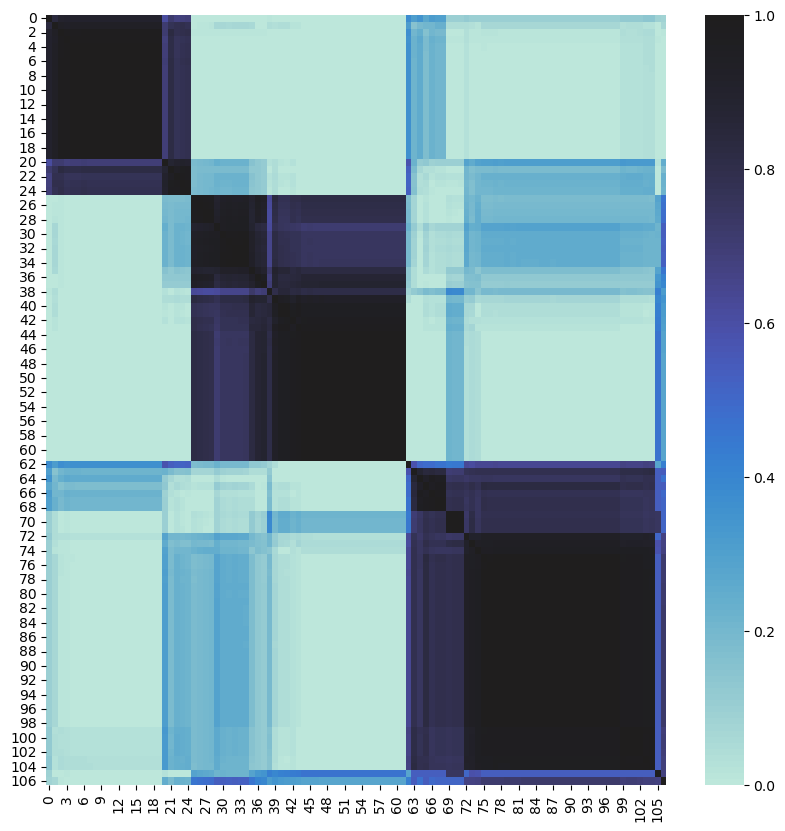

In [14]:
plt.figure(figsize=(10,10))
sns.heatmap(psm_sorted, center=1)
plt.show()

In [15]:
def binder_loss(psm, labels):
    # expected Binder loss from PSM (sum over i<j)
    labels = np.asarray(labels)
    A = (labels[:, None] == labels[None, :]).astype(float)
    iu = np.triu_indices(psm.shape[0], k=1)
    return float(np.sum(np.abs(A[iu] - psm[iu])))

def binder_optimal_partition(psm, k_min, k_max):
    psm = np.asarray(psm, dtype=float)
    psm = 0.5 * (psm + psm.T)
    np.fill_diagonal(psm, 1.0)

    dist = 1.0 - psm
    np.fill_diagonal(dist, 0.0)

    best_loss = np.inf
    best_labels = None

    for k in range(k_min, min(k_max, psm.shape[0]) + 1):
        model = AgglomerativeClustering(
            n_clusters=k,
            linkage="average",
            metric="precomputed",  
        )
        labels = model.fit_predict(dist)
        loss = binder_loss(psm, labels)
        if loss < best_loss:
            best_loss = loss
            best_labels = labels

    return best_labels, best_loss

In [16]:
labels_opt, loss_opt = binder_optimal_partition(psm, k_min=1, k_max=5)

In [17]:
labels_opt

array([2, 2, 0, 0, 2, 1, 2, 2, 0, 0, 2, 0, 0, 2, 2, 1, 2, 2, 0, 2, 2, 2,
       0, 0, 2, 0, 1, 0, 2, 0, 2, 1, 2, 1, 0, 2, 0, 1, 0, 0, 0, 1, 1, 0,
       2, 2, 2, 2, 0, 0, 0, 0, 2, 2, 1, 2, 1, 1, 0, 0, 0, 0, 0, 2, 0, 2,
       0, 0, 1, 1, 0, 1, 2, 1, 0, 1, 0, 1, 1, 0, 2, 1, 1, 2, 2, 2, 2, 0,
       0, 0, 0, 2, 0, 0, 0, 0, 2, 1, 0, 1, 0, 1, 2, 1, 2, 0, 1])

In [18]:
labels = labels_opt + 1

In [19]:
labels

array([3, 3, 1, 1, 3, 2, 3, 3, 1, 1, 3, 1, 1, 3, 3, 2, 3, 3, 1, 3, 3, 3,
       1, 1, 3, 1, 2, 1, 3, 1, 3, 2, 3, 2, 1, 3, 1, 2, 1, 1, 1, 2, 2, 1,
       3, 3, 3, 3, 1, 1, 1, 1, 3, 3, 2, 3, 2, 2, 1, 1, 1, 1, 1, 3, 1, 3,
       1, 1, 2, 2, 1, 2, 3, 2, 1, 2, 1, 2, 2, 1, 3, 2, 2, 3, 3, 3, 3, 1,
       1, 1, 1, 3, 1, 1, 1, 1, 3, 2, 1, 2, 1, 2, 3, 2, 3, 1, 2])

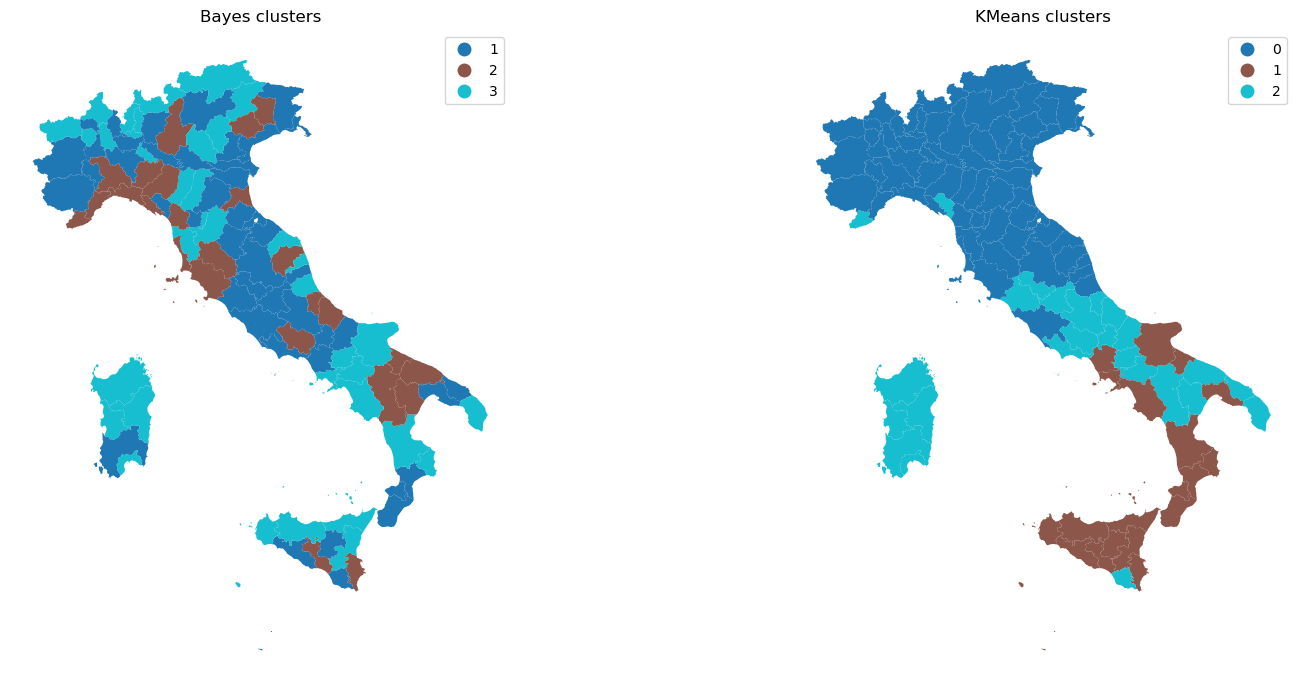

In [52]:
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# gdf: GeoDataFrame with one row per observation/region
# must have a geometry column of polygons/multipolygons
gdf = gpd.read_file("../data/updated_data.geojson")
gdf["cluster_bayes"] = labels

kmeans = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(y_star.reshape(-1, 1))
gdf["cluster"] = kmeans.labels_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

gdf.plot(column="cluster_bayes", categorical=True, legend=True, ax=ax1)
ax1.set_title("Bayes clusters")
ax1.set_axis_off()

gdf.plot(column="cluster", categorical=True, legend=True, ax=ax2)
ax2.set_title("KMeans clusters")
ax2.set_axis_off()

plt.tight_layout()
plt.show()


In [20]:
with open("labels.txt", "w") as f:
    for x in labels:
        f.write(f"{x}\n")

## "Final" Model

Actually we still have to add in the model the spatial effect

In [40]:
model = """
data {
  int<lower=1> N;                // number of observations
  int<lower=1> P;                // number of predictors (excluding intercept)
  int<lower=1> C;                // number of clusters
  array[N] int<lower=1, upper=C> cluster; // cluster label for each observation (1..C)
  matrix[N, P] X;                // predictor matrix
  vector[N] y;                   // outcome vector
  vector[N] x_offset; 
}
parameters {
  vector[C] alpha;               // intercept for each cluster
  matrix[C, P] beta;             // coefficient vector (slopes) for each cluster
  vector<lower=1e-6>[C] sigma;      // noise std dev for each cluster
}
model {
  // Priors (weakly informative)
  alpha ~ normal(0, 3);                      // intercepts (allow wide range)
  to_vector(beta) ~ normal(0, 3);             // all slope coefficients flattened
  sigma ~ cauchy(0, 2);                       // sigma > 0, half-Cauchy (or half-normal) prior
  
  // Likelihood: each data point uses parameters of its cluster
  for (n in 1:N) {
    int c = cluster[n];
    y[n] ~ normal(alpha[c] + X[n] * beta[c]' + x_offset[n], sigma[c]);
  }
}
"""

In [41]:
with open("labeled_model.stan", "w") as f:
    f.write(model)

In [ ]:
data_m = {
    "N": int(N),
    "P": int(P),
    "C": int(K),
    "cluster": labels.astype(int),
    "X": X_star.astype(float),
    "y": y_star.astype(float),
    "x_offset": offset_star.astype(float),
}

In [ ]:
mix_stan_m = CmdStanModel(stan_file="labeled_model.stan")

16:44:00 - cmdstanpy - INFO - compiling stan file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\labeled_model.stan to exe file C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\labeled_model.exe
16:45:19 - cmdstanpy - INFO - compiled model executable: C:\Users\leona\Desktop\POLIMI\Programmi\BayesianStat\Bayesian-Statistics-Project\sandbox\mixture_model\labeled_model.exe


In [ ]:
fit_m = mix_stan_m.sample(
    data=data_m,
    chains=4,
    iter_warmup=2000,
    iter_sampling=2000,
    adapt_delta=0.95,
    max_treedepth=12
)

16:47:44 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/4000 [00:00<?, ?it/s, (Warmup)]

16:47:46 - cmdstanpy - INFO - CmdStan done processing.
